In [6]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Pada bagian ini kita mengimpor semua library yang dibutuhkan dan memuat dataset

In [8]:
path = "/content/gdrive/MyDrive/machine learning/praktikum/praktikum7"

In [9]:
df = pd.read_csv(path + "/data/dataset_satelit.csv", sep=",")
df.head()

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         594 non-null    int64  
 1   Longitude  594 non-null    float64
 2   Lattitude  594 non-null    float64
 3   N          594 non-null    float64
 4   P          594 non-null    float64
 5   K          593 non-null    float64
 6   Ca         594 non-null    float64
 7   Mg         594 non-null    object 
 8   Fe         594 non-null    float64
 9   Mn         594 non-null    float64
 10  Cu         594 non-null    float64
 11  Zn         594 non-null    float64
 12  B          594 non-null    float64
 13  b12        594 non-null    float64
 14  b11        594 non-null    float64
 15  b9         594 non-null    float64
 16  b8a        594 non-null    float64
 17  b8         594 non-null    float64
 18  b7         594 non-null    float64
 19  b6         594 non-null    float64
 20  b5        

In [11]:
df.describe()

,No,Longitude,Lattitude,N,P,K,Ca,Fe,Mn,Cu,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
count,594.000000,594.000000,594.000000,594.000000,594.000000,593.000000,594.000000,594.000000,594.000000,594.000000,...,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000
mean,297.500000,106.878644,-1.024933,2.259091,0.141380,0.582175,0.595094,74.613771,308.034697,2.391195,...,0.177291,0.234474,0.102789,28.640422,28.664891,28.609569,0.202587,0.051524,0.269642,0.062320
std,171.617307,4.949840,0.965349,0.395499,0.019782,0.222567,0.366118,55.579655,241.731643,1.580296,...,0.155615,0.070516,0.112310,15.325347,15.380384,15.329170,0.104357,0.012959,0.143728,0.024218
min,1.000000,102.760857,-2.333750,1.140000,0.090000,0.122000,0.050000,21.080000,3.160000,0.090000,...,0.014100,0.115170,0.021460,0.127000,0.098600,0.026000,0.008700,0.016900,0.009300,0.016300
25%,149.250000,102.927811,-2.233338,1.982500,0.130000,0.429000,0.320000,40.705000,124.015000,1.172500,...,0.046925,0.183210,0.039535,31.959745,31.968948,33.685353,0.183085,0.040250,0.244935,0.052772
50%,297.500000,103.581969,-0.602276,2.280000,0.140000,0.549000,0.540000,65.650000,239.445000,2.225000,...,0.072700,0.213385,0.046550,35.067930,35.110415,34.611565,0.233590,0.050415,0.310380,0.068380
75%,445.750000,113.403797,-0.257349,2.570000,0.150000,0.710000,0.790000,87.372500,434.990000,3.357500,...,0.318900,0.262242,0.059190,38.319135,38.441065,39.002760,0.271790,0.060410,0.364505,0.079020
max,594.000000,113.434700,0.069251,3.230000,0.220000,1.489000,2.820000,559.100000,2009.320000,8.170000,...,0.751400,0.512210,0.373000,47.592900,48.014640,39.209330,0.658960,0.122300,0.814170,0.150620


In [12]:
X = df[['gamma0_vv', 'gamma0_vh']]
y = df['Fe']

X.head(), y.head()

(   gamma0_vv  gamma0_vh
 0    0.22331    0.05479
 1    0.27116    0.05699
 2    0.23242    0.04902
 3    0.18138    0.04448
 4    0.22359    0.04664,
 0    119.96
 1    102.63
 2    107.37
 3     96.02
 4     87.01
 Name: Fe, dtype: float64)

Di sini kita memilih kolom `gamma0_vv` dan `gamma0_vh` sebagai variabel input, serta `Fe` sebagai variabel target.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
len(X_train), len(X_test)

(475, 119)

Data dibagi menjadi 80% untuk pelatihan dan 20% untuk pengujian.

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept  :", model.intercept_)
print("Koefisien  :", model.coef_)

Intercept  : 126.849412571108
Koefisien  : [   80.20446277 -1365.46992884]


Model dilatih menggunakan data training.

In [15]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)
print("Akurasi (persentase):", accuracy, "%")

MAE : 33.47415762965465
MSE : 4134.322719701519
RMSE: 64.29869920691647
R² Score: 0.02630761725809183
Akurasi (persentase): 2.630761725809183 %


Mengukur performa model menggunakan MAE, MSE, RMSE, R² dan menghitung akurasi persentase.

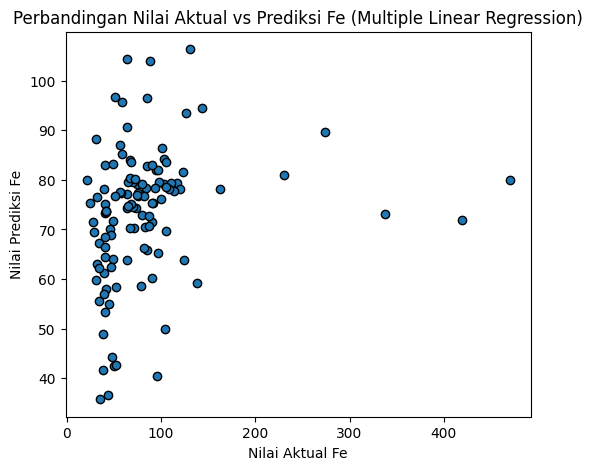

In [16]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, edgecolor='k')
plt.xlabel("Nilai Aktual Fe")
plt.ylabel("Nilai Prediksi Fe")
plt.title("Perbandingan Nilai Aktual vs Prediksi Fe (Multiple Linear Regression)")
plt.show()

Grafik scatter menunjukkan seberapa dekat hasil prediksi terhadap nilai sebenarnya.

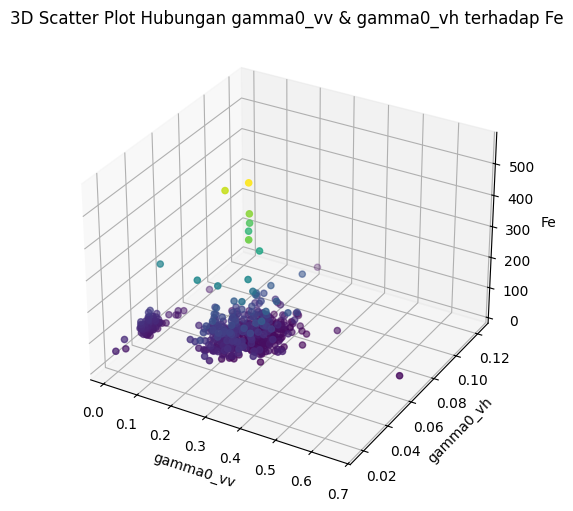

In [17]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['gamma0_vv'], df['gamma0_vh'], df['Fe'], c=df['Fe'], cmap='viridis')
ax.set_xlabel("gamma0_vv")
ax.set_ylabel("gamma0_vh")
ax.set_zlabel("Fe")
ax.set_title("3D Scatter Plot Hubungan gamma0_vv & gamma0_vh terhadap Fe")
plt.show()

Scatter plot 3D membantu melihat pola hubungan gamma0_vv, gamma0_vh, dan Fe.